In [3]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('playground-series-s6e7')

print("Path to competition files:", path)

Path to competition files: /kaggle/input/competitions/playground-series-s6e7


In [4]:
import pandas as pd

train = pd.read_csv("/kaggle/input/competitions/playground-series-s6e7/train.csv")
test = pd.read_csv("/kaggle/input/competitions/playground-series-s6e7/test.csv")
sample_submission = pd.read_csv(
    "/kaggle/input/competitions/playground-series-s6e7/sample_submission.csv"
)

print(train.shape)
print(test.shape)
print(sample_submission.shape)

(690088, 15)
(295753, 14)
(295753, 2)


In [5]:
display(train.head())
display(test.head())
display(sample_submission.head())

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,690088,5.35,64.9,23.48,2745.0,14167.0,59.5,1.86,veg,high,poor,active,occasional,male
1,690089,NaN,83.1,22.42,1773.0,6801.0,24.5,2.40,balanced,high,poor,sedentary,yes,other
2,690090,6.68,59.7,24.14,3040.0,13250.0,48.5,2.76,balanced,medium,poor,active,no,NaN
3,690091,7.13,78.5,26.26,2494.0,6331.0,56.9,2.34,veg,low,good,moderate,yes,other
4,690092,5.49,77.7,23.29,1828.0,13894.0,39.4,2.45,veg,high,average,active,occasional,other


,id,health_condition
0,690088,at-risk
1,690089,at-risk
2,690090,at-risk
3,690091,at-risk
4,690092,at-risk


결측치

In [6]:
# Train 결측치 확인
train_missing = pd.DataFrame({
    'Missing Count': train.isnull().sum(),
    'Missing Ratio (%)': train.isnull().mean() * 100
}).sort_values('Missing Ratio (%)', ascending=False)

print("=== Train Missing Values ===")
display(train_missing)


# Test 결측치 확인
test_missing = pd.DataFrame({
    'Missing Count': test.isnull().sum(),
    'Missing Ratio (%)': test.isnull().mean() * 100
}).sort_values('Missing Ratio (%)', ascending=False)

print("=== Test Missing Values ===")
display(test_missing)

=== Train Missing Values ===


,Missing Count,Missing Ratio (%)
stress_level,82811,12.000064
sleep_duration,75999,11.012943
sleep_quality,58331,8.452690
calorie_expenditure,52853,7.658878
water_intake,43477,6.300211
physical_activity_level,36621,5.306715
smoking_alcohol,28582,4.141791
gender,21373,3.097141
step_count,13916,2.016554
bmi,13898,2.013946


=== Test Missing Values ===


,Missing Count,Missing Ratio (%)
stress_level,35490,11.999878
sleep_duration,32571,11.012906
sleep_quality,24999,8.452662
calorie_expenditure,22652,7.659094
water_intake,18633,6.300190
physical_activity_level,15695,5.306793
smoking_alcohol,12249,4.141632
gender,9160,3.097179
step_count,5964,2.016548
bmi,5956,2.013843


In [7]:
print("=== Train Missing Values ===")
display(
    train_missing[train_missing['Missing Count'] > 0]
)

print("=== Test Missing Values ===")
display(
    test_missing[test_missing['Missing Count'] > 0]
)

=== Train Missing Values ===


,Missing Count,Missing Ratio (%)
stress_level,82811,12.000064
sleep_duration,75999,11.012943
sleep_quality,58331,8.452690
calorie_expenditure,52853,7.658878
water_intake,43477,6.300211
physical_activity_level,36621,5.306715
smoking_alcohol,28582,4.141791
gender,21373,3.097141
step_count,13916,2.016554
bmi,13898,2.013946


=== Test Missing Values ===


,Missing Count,Missing Ratio (%)
stress_level,35490,11.999878
sleep_duration,32571,11.012906
sleep_quality,24999,8.452662
calorie_expenditure,22652,7.659094
water_intake,18633,6.300190
physical_activity_level,15695,5.306793
smoking_alcohol,12249,4.141632
gender,9160,3.097179
step_count,5964,2.016548
bmi,5956,2.013843


In [8]:
missing_compare = pd.DataFrame({
    'Train Missing (%)': train.isnull().mean() * 100,
    'Test Missing (%)': test.isnull().mean() * 100
}).round(2)

missing_compare = missing_compare[
    (missing_compare['Train Missing (%)'] > 0) |
    (missing_compare['Test Missing (%)'] > 0)
].sort_values('Train Missing (%)', ascending=False)

display(missing_compare)

,Train Missing (%),Test Missing (%)
stress_level,12.00,12.00
sleep_duration,11.01,11.01
sleep_quality,8.45,8.45
calorie_expenditure,7.66,7.66
water_intake,6.30,6.30
physical_activity_level,5.31,5.31
smoking_alcohol,4.14,4.14
gender,3.10,3.10
step_count,2.02,2.02
bmi,2.01,2.01


비율

In [9]:
train['health_condition'].value_counts(normalize=True) * 100

health_condition
at-risk      85.867455
unhealthy     8.364730
fit           5.767815
Name: proportion, dtype: float64

In [10]:
health_dist = pd.DataFrame({
    'Count': train['health_condition'].value_counts(),
    'Ratio (%)': train['health_condition'].value_counts(normalize=True) * 100
})

health_dist['Ratio (%)'] = health_dist['Ratio (%)'].round(2)

display(health_dist)

,Count,Ratio (%)
health_condition,,
at-risk,592561,85.87
unhealthy,57724,8.36
fit,39803,5.77


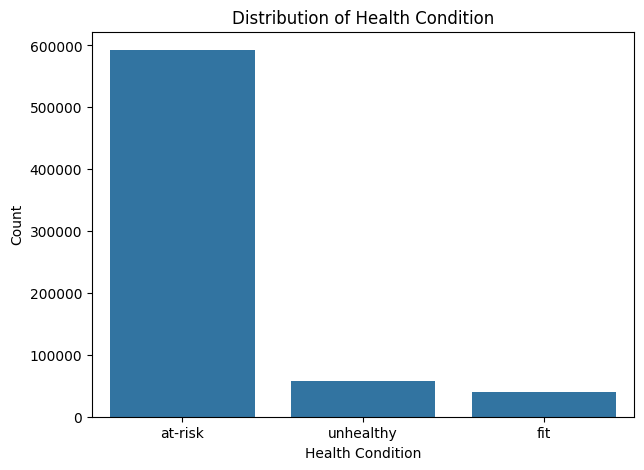

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.countplot(
    data=train,
    x='health_condition',
    order=train['health_condition'].value_counts().index
)

plt.title('Distribution of Health Condition')
plt.xlabel('Health Condition')
plt.ylabel('Count')
plt.show()

수치형 - 비율

In [12]:
numeric_features = [
    'sleep_duration',
    'heart_rate',
    'bmi',
    'calorie_expenditure',
    'exercise_duration',
    'step_count',
    'water_intake'
]


"""
numeric_features = train.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

# id는 분석에서 제외
if 'id' in numeric_features:
    numeric_features.remove('id')

print(numeric_features)
"""

"\nnumeric_features = train.select_dtypes(\n    include=['int64', 'float64']\n).columns.tolist()\n\n# id는 분석에서 제외\nif 'id' in numeric_features:\n    numeric_features.remove('id')\n\nprint(numeric_features)\n"

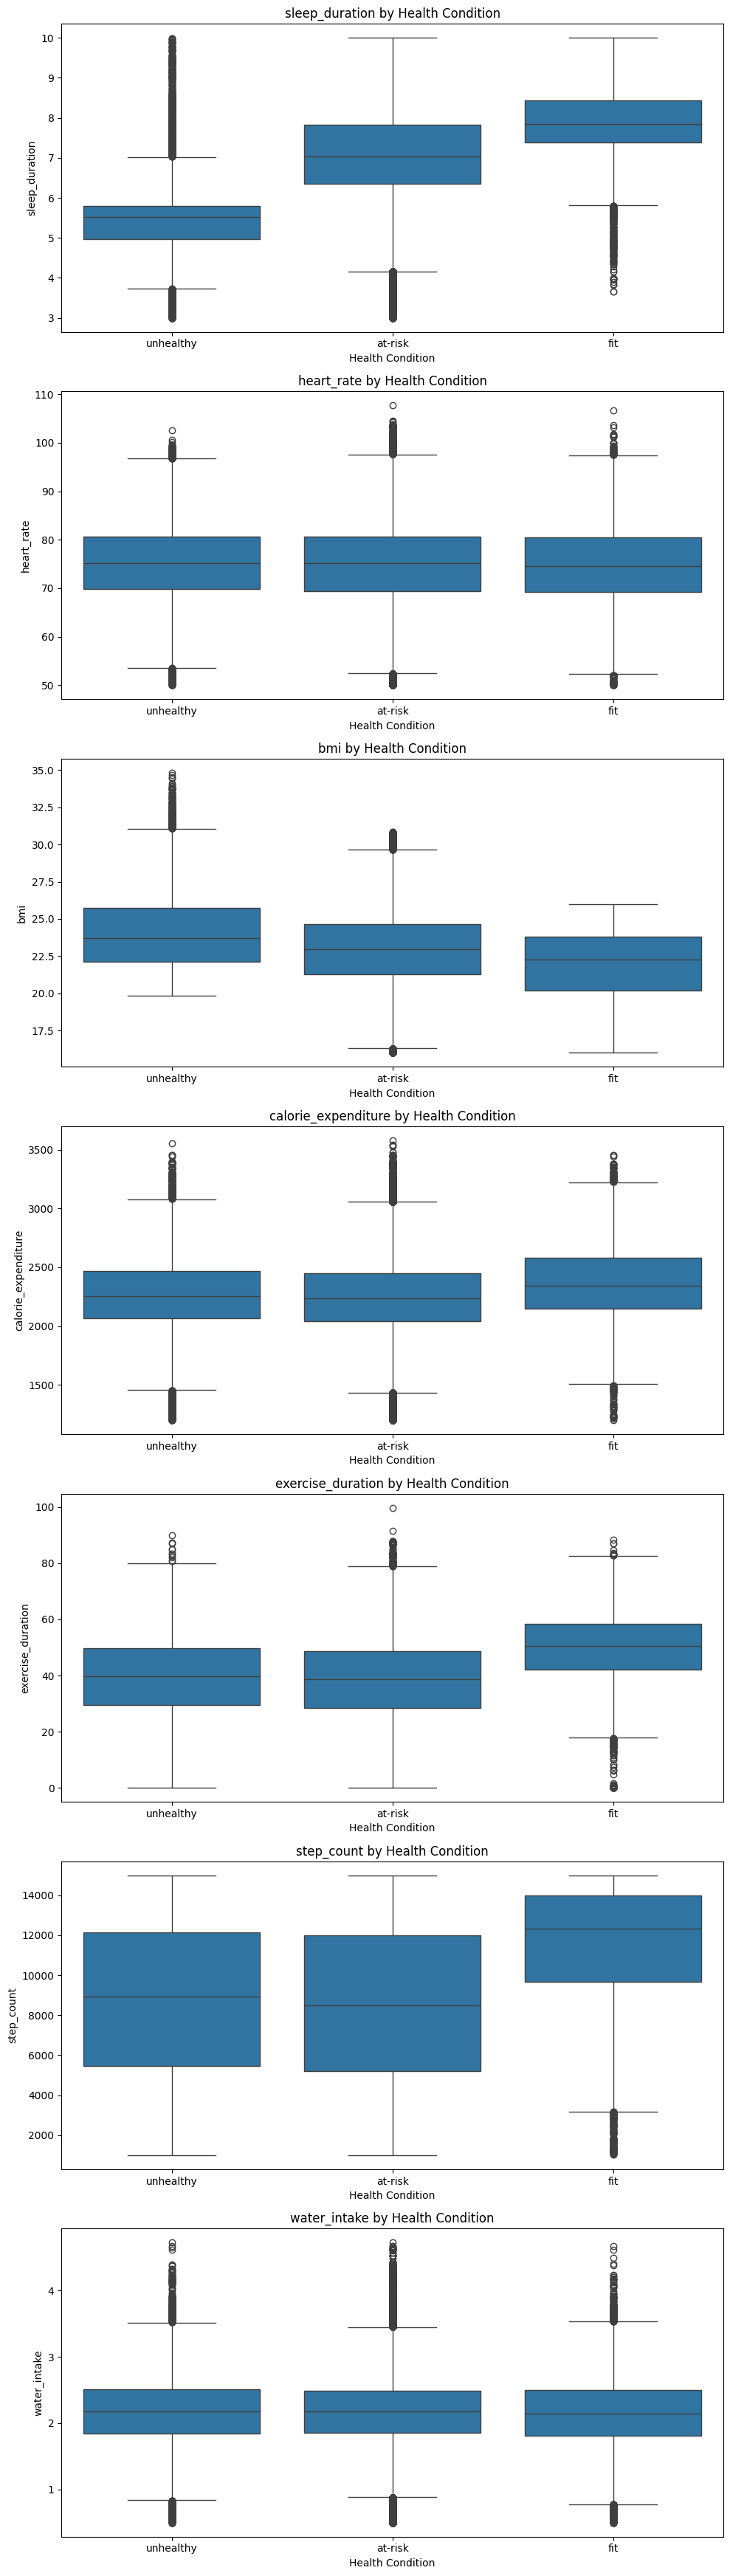

In [13]:
fig, axes = plt.subplots(
    nrows=len(numeric_features),
    ncols=1,
    figsize=(10, 5 * len(numeric_features))
)

for ax, col in zip(axes, numeric_features):
    
    sns.boxplot(
        data=train,
        x='health_condition',
        y=col,
        ax=ax
    )
    
    ax.set_title(f'{col} by Health Condition')
    ax.set_xlabel('Health Condition')
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

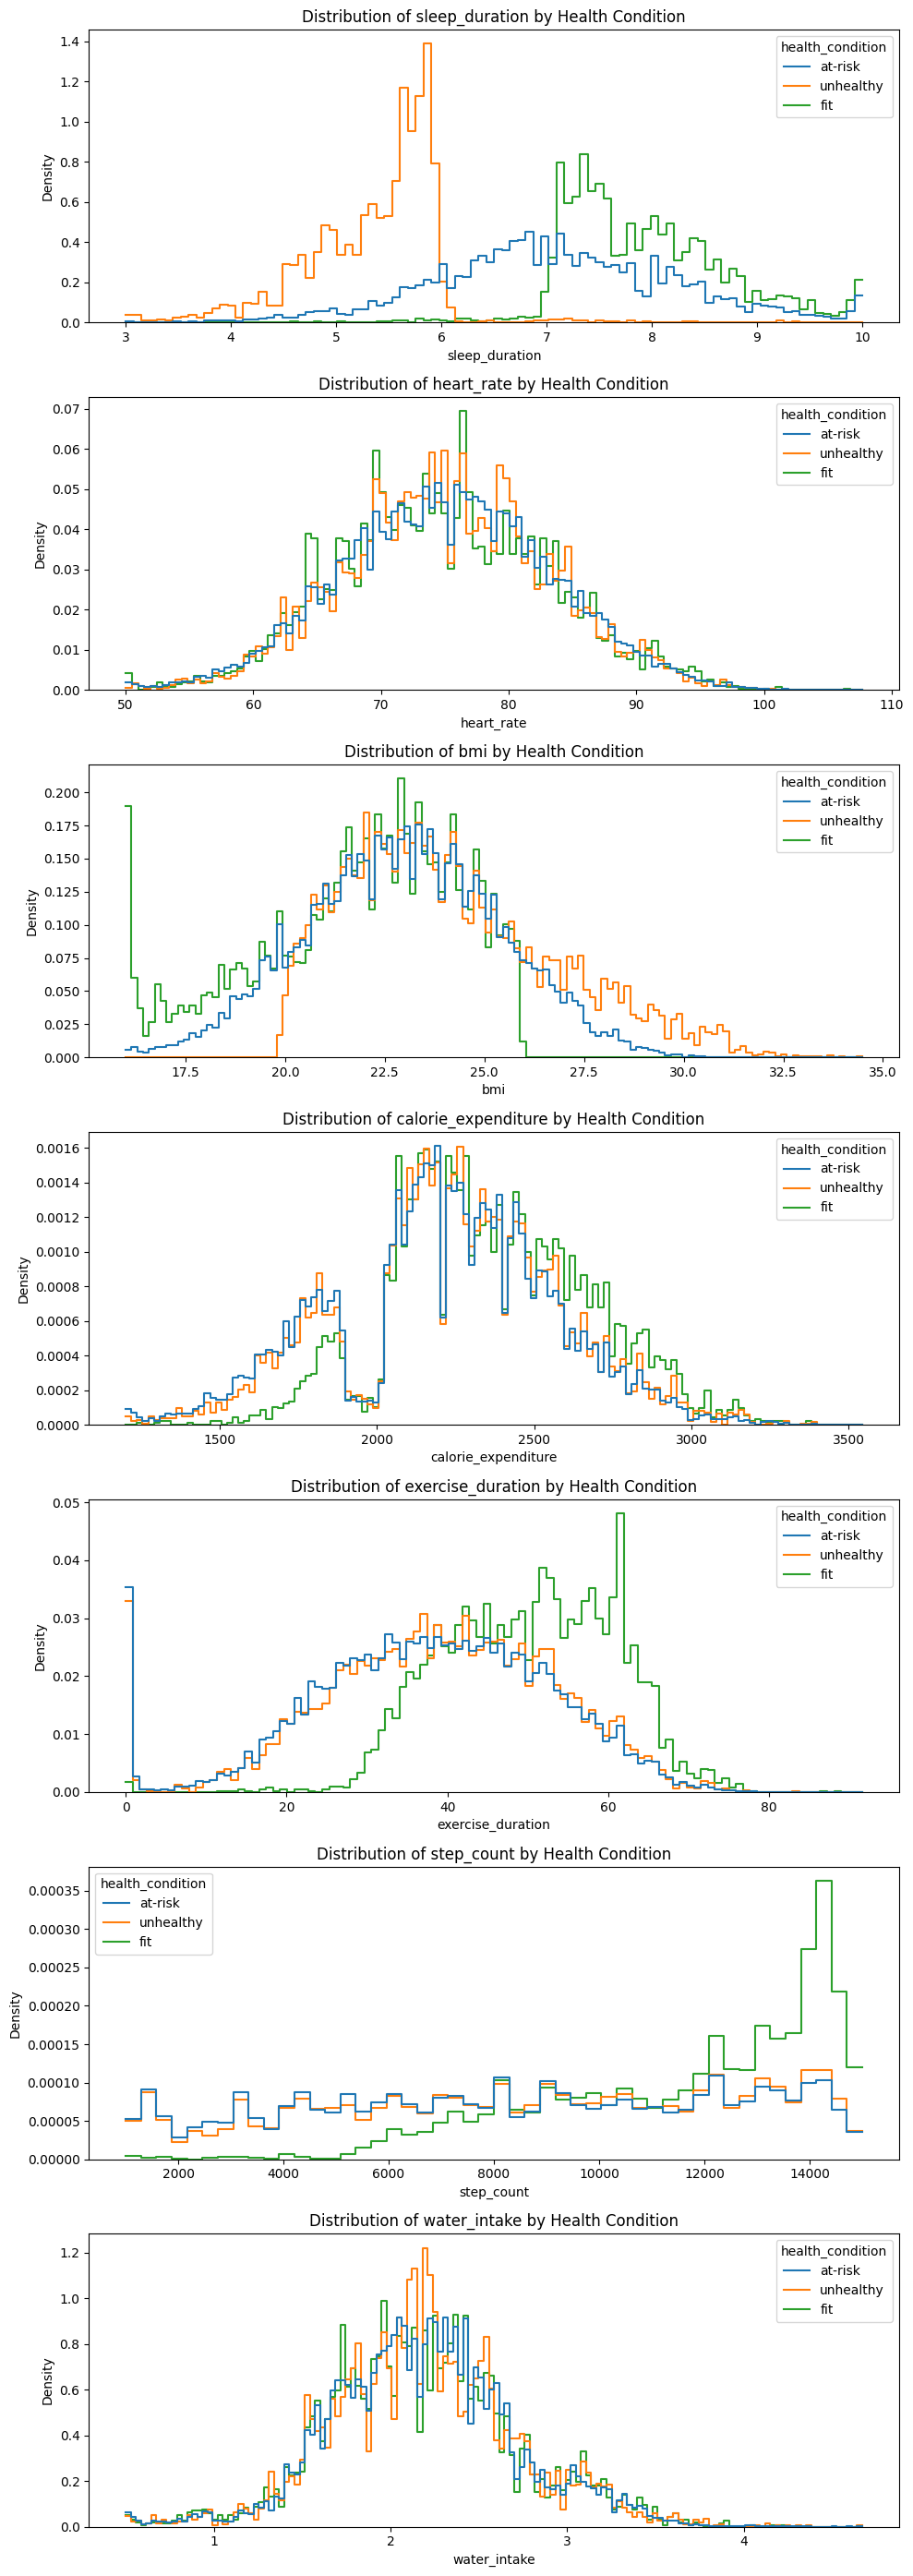

In [14]:
# 시각화 속도를 위해 샘플링
plot_data = train.sample(
    n=min(100000, len(train)),
    random_state=42
)

fig, axes = plt.subplots(
    nrows=len(numeric_features),
    ncols=1,
    figsize=(10, 4 * len(numeric_features))
)

for ax, col in zip(axes, numeric_features):
    
    sns.histplot(
        data=plot_data,
        x=col,
        hue='health_condition',
        stat='density',
        common_norm=False,
        element='step',
        fill=False,
        ax=ax
    )
    
    ax.set_title(f'Distribution of {col} by Health Condition')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')

plt.tight_layout()
plt.show()

In [16]:
categorical_features = train.select_dtypes(
    include=['object', 'category', 'bool']
).columns.tolist()

# target 제외
if 'health_condition' in categorical_features:
    categorical_features.remove('health_condition')

print(categorical_features)

['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']


In [17]:
for col in train.columns:
    print(col, train[col].nunique())

id 690088
health_condition 3
sleep_duration 701
heart_rate 537
bmi 1596
calorie_expenditure 2101
step_count 12807
exercise_duration 856
water_intake 400
diet_type 3
stress_level 3
sleep_quality 3
physical_activity_level 3
smoking_alcohol 3
gender 3


In [18]:
for col in categorical_features:
    
    ratio = pd.crosstab(
        train[col],
        train['health_condition'],
        normalize='index'
    ) * 100
    
    print(f'\n=== {col} ===')
    display(ratio.round(2))


=== diet_type ===


health_condition,at-risk,fit,unhealthy
diet_type,,,
balanced,85.14,6.12,8.74
non-veg,86.78,5.16,8.06
veg,85.67,6.04,8.30



=== stress_level ===


health_condition,at-risk,fit,unhealthy
stress_level,,,
high,71.78,0.35,27.87
low,79.67,20.06,0.28
medium,99.39,0.30,0.31



=== sleep_quality ===


...

health_condition,at-risk,fit,unhealthy
physical_activity_level,,,
active,74.31,17.16,8.53
moderate,91.15,0.31,8.54
sedentary,91.73,0.24,8.03



=== smoking_alcohol ===


health_condition,at-risk,fit,unhealthy
smoking_alcohol,,,
no,86.68,7.86,5.46
occasional,85.85,5.78,8.36
yes,85.10,3.70,11.20



=== gender ===


health_condition,at-risk,fit,unhealthy
gender,,,
female,85.74,5.71,8.55
male,85.70,6.26,8.05
other,86.21,5.29,8.50


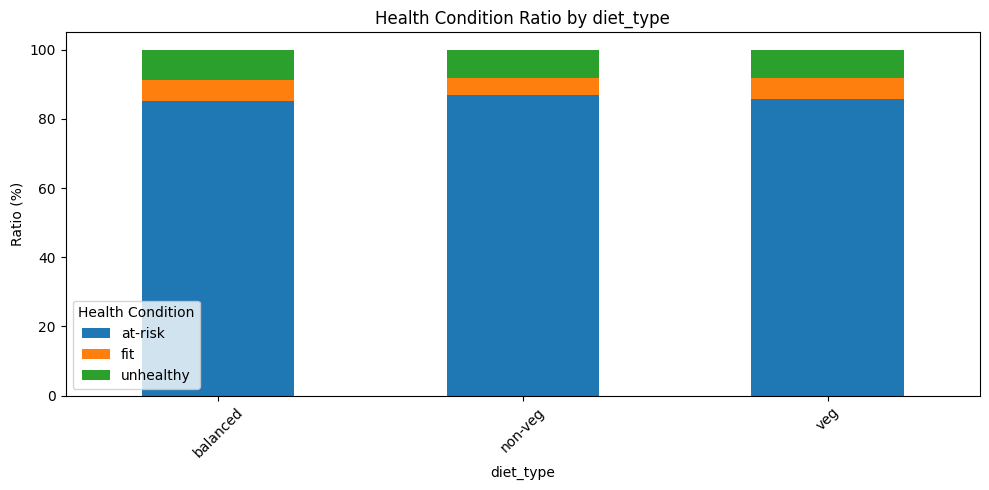

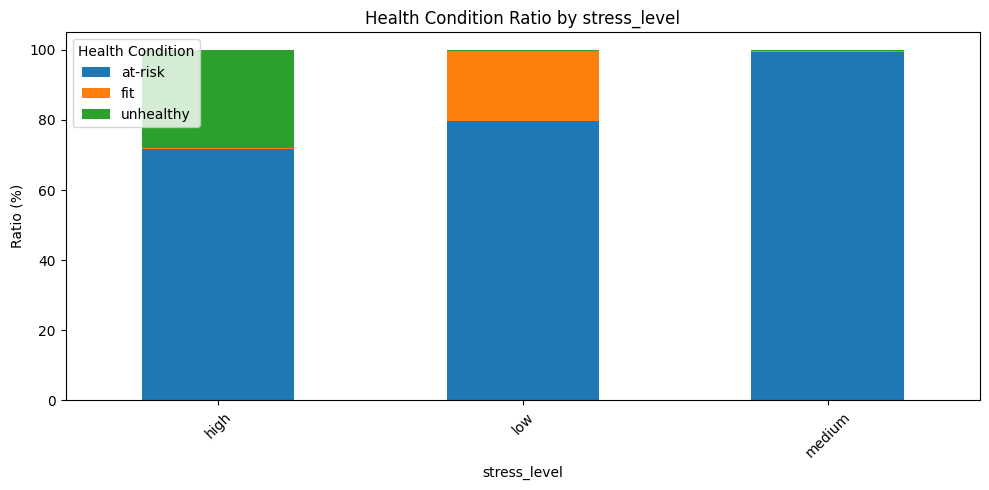

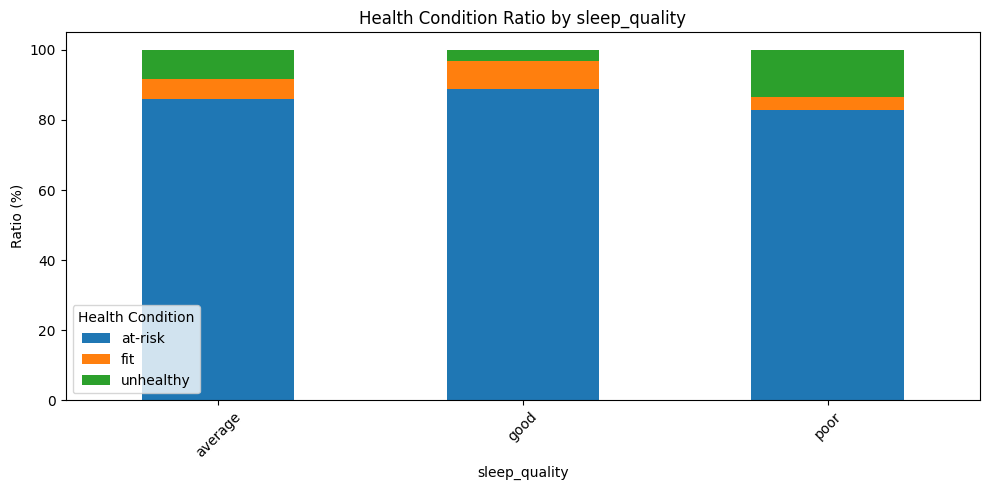

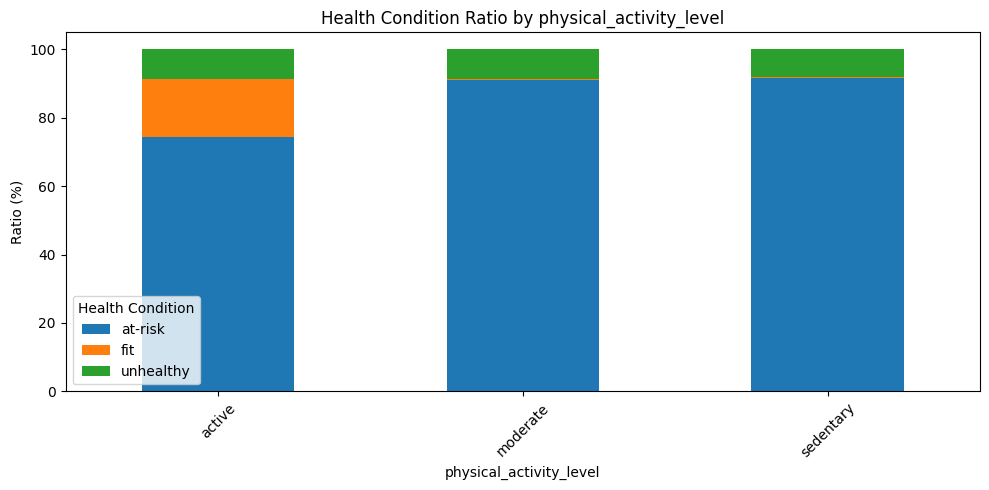

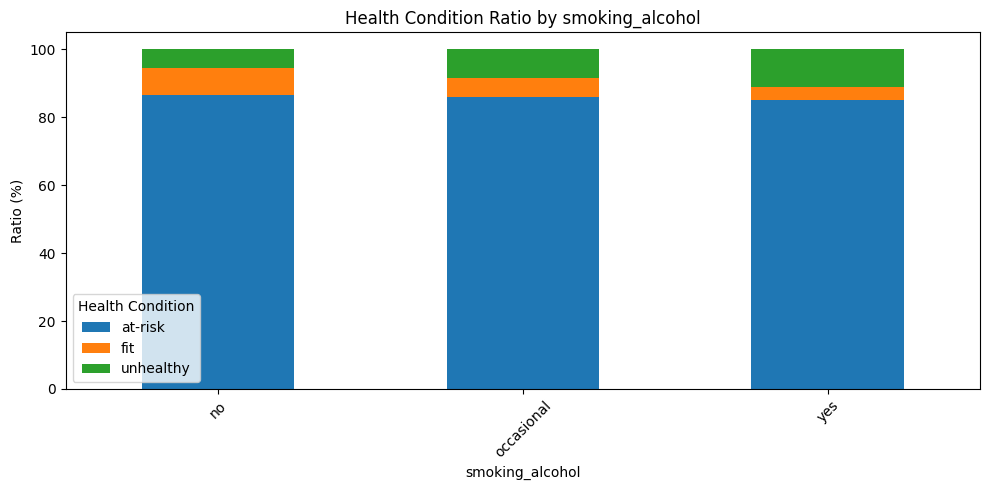

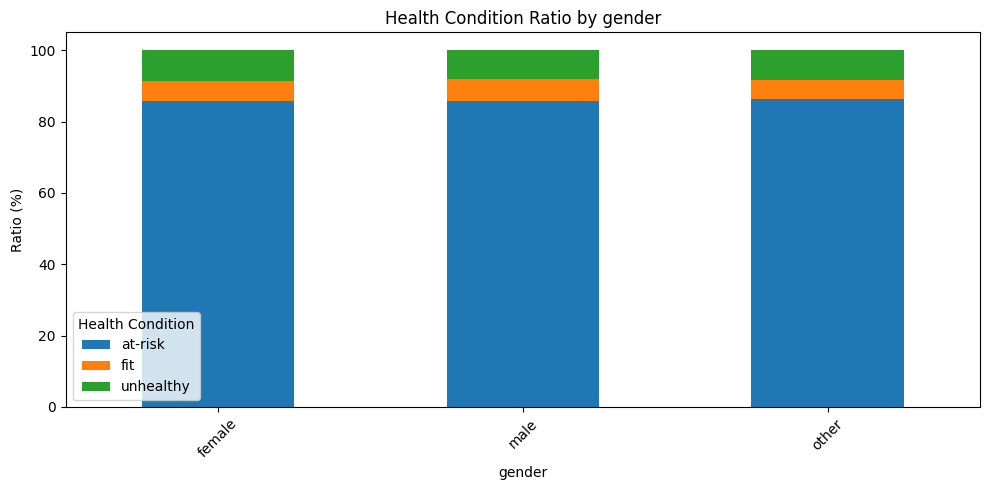

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

for col in categorical_features:
    
    ratio = pd.crosstab(
        train[col],
        train['health_condition'],
        normalize='index'
    ) * 100
    
    ratio.plot(
        kind='bar',
        stacked=True,
        figsize=(10, 5)
    )
    
    plt.title(f'Health Condition Ratio by {col}')
    plt.xlabel(col)
    plt.ylabel('Ratio (%)')
    plt.legend(title='Health Condition')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [20]:
train.shape
train.info()
train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  object 
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  object 
 10  stress_level             607277 non-null  object 
 11  sleep_quality            631757 non-null  object 
 12  physical_activity_level  653467 non-null  object 
 13  smoking_alcohol          661506 non-null  object 
 14  gend

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
count,690088.00000,614089.000000,682255.000000,676190.000000,637235.000000,676172.000000,683187.000000,646611.000000
mean,345043.50000,6.992597,75.096504,22.984925,2226.084931,8615.953050,38.751456,2.188542
std,199211.39062,1.215407,8.175106,2.481787,347.532098,3929.399831,14.742189,0.518489
min,0.00000,3.000000,50.000000,16.000000,1200.000000,1002.000000,0.000000,0.500000
25%,172521.75000,6.160000,69.400000,21.320000,2053.000000,5389.000000,29.200000,1.840000
50%,345043.50000,6.990000,75.100000,22.990000,2241.000000,8856.000000,39.400000,2.170000
75%,517565.25000,7.810000,80.700000,24.660000,2456.000000,12114.000000,49.400000,2.500000
max,690087.00000,10.000000,107.700000,34.820000,3580.000000,14999.000000,99.800000,4.720000
